In [11]:
import pandas as pd
import numpy as np
df=pd.read_csv('habitable_planets.csv')
print("data successfully load top 5 lines:")
print(df.head())




data successfully load top 5 lines:
   planet_id   planet_name planet_status  planet_size_earths  \
0         87  Kepler-235 e     CONFIRMED                1.83   
1        170  Kepler-705 b     CONFIRMED                1.94   
2        532  Kepler-267 d     CONFIRMED                1.87   
3        560  Kepler-737 b     CONFIRMED                1.83   
4        973  Kepler-296 d     CONFIRMED                1.52   

   planet_temperature_k_elvin orbital_period_days  orbital_period_upper_err1  \
0                         273          koi_period                   0.000265   
1                         233          koi_period                   0.000275   
2                         301          koi_period                   0.000088   
3                         298          koi_period                   0.000055   
4                         297          koi_period                   0.000055   

   orbital_period_lower_err2  
0                  -0.000265  
1                  -0.000275  
2    

In [12]:
df['is_habitable'] = ((df['planet_temperature_k_elvin'] >= 200) & (df['planet_temperature_k_elvin'] <= 320)).astype(int)
X = df[['planet_size_earths', 'planet_temperature_k_elvin']]
y = df['is_habitable']

print("Features (X) and Target (y) are ready!")
print("\n--- X Head ---")
print(X.head())
print("\n--- y Head ---")
print(y.head())

Features (X) and Target (y) are ready!

--- X Head ---
   planet_size_earths  planet_temperature_k_elvin
0                1.83                         273
1                1.94                         233
2                1.87                         301
3                1.83                         298
4                1.52                         297

--- y Head ---
0    1
1    1
2    1
3    1
4    1
Name: is_habitable, dtype: int64


In [14]:
!pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/83/a4/c8e67227c680e2259c8864ae72ff48b06e16a6f51253a22167aa02a8aa4e/scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/a2/84/dc08d77fbf3d87d3ee27f6a0c6dcce1de5829a64f2eae85a0ecc1f0daa73/scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------------- ------------ 41.0/61.0 kB 245.8 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 262.6 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 249.8 kB/s eta 0:00:00
  Obtaining dependency information for


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X, y)

print("machine learning model successfully trained")

machine learning model successfully trained


In [16]:
new_planet_data = [[2.5, 250]]
planet_prediction = model.predict(new_planet_data)
print("Prediction Results:")
if planet_prediction[0] == 1:
    print("Status: Habitable Planet (Class 1)")
else:
    print("Status: Non-Habitable Planet (Class 0)")

Prediction Results:
Status: Habitable Planet (Class 1)


c:\Users\shara\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [17]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Split the dataset into 80% training and 20% testing sets to prevent overfitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Classifier algorithm
evaluated_model = DecisionTreeClassifier()

# Fit the model using the training subset
evaluated_model.fit(X_train, y_train)

# Generate predictions on the unseen validation dataset
y_pred = evaluated_model.predict(X_test)

# Evaluate performance by comparing predictions with actual labels
model_accuracy = accuracy_score(y_test, y_pred)

print("Model Evaluation Completed.")
print(f"Model Accuracy Score: {model_accuracy * 100:.2f}%")

Model Evaluation Completed.
Model Accuracy Score: 100.00%


In [18]:
!pip install matplotlib seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 131.3 kB/s eta 0:00:03
   ---- ---------------------------------- 30.7/294.9 kB 131.3 kB/s eta 0:00:03
   ----- --------------------------------- 41.0/294.9 kB 151.3 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/294.9 kB 151


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


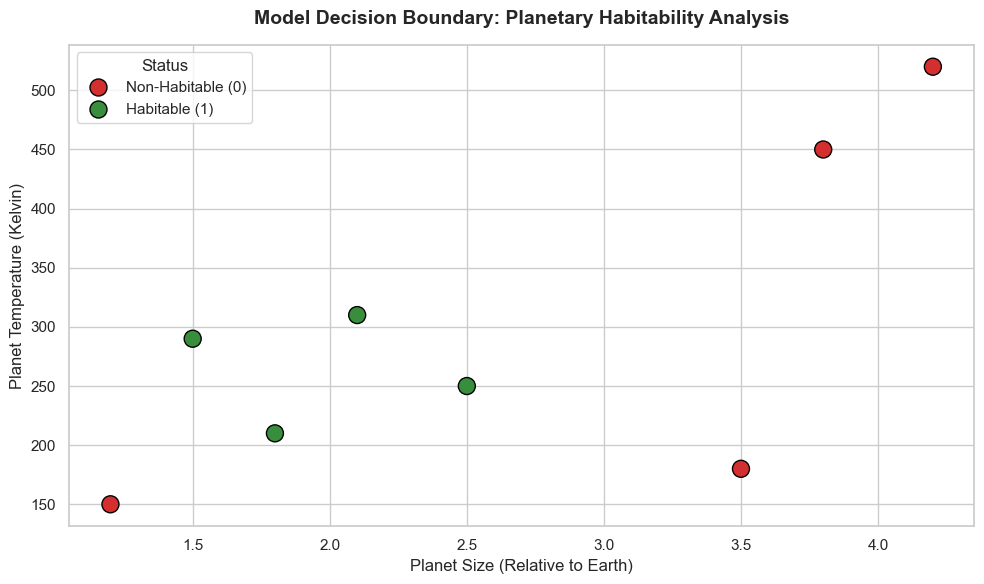

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sample_sizes = [1.2, 2.5, 3.8, 1.5, 4.2, 2.1, 1.8, 3.5]
sample_temps = [150, 250, 450, 290, 520, 310, 210, 180]
df_plot = pd.DataFrame({
    'planet_size_earths': sample_sizes,
    'planet_temperature_k_elvin': sample_temps
})

df_plot['Status'] = np.where(
    (df_plot['planet_temperature_k_elvin'] >= 200) & (df_plot['planet_temperature_k_elvin'] <= 320),
    'Habitable (1)',
    'Non-Habitable (0)'
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

custom_colors = {'Non-Habitable (0)': '#d32f2f', 'Habitable (1)': '#388e3c'}

sns.scatterplot(
    data=df_plot,
    x='planet_size_earths', 
    y='planet_temperature_k_elvin', 
    hue='Status', 
    palette=custom_colors, 
    s=150, 
    marker='o',
    edgecolor='black'
)
plt.title("Model Decision Boundary: Planetary Habitability Analysis", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Planet Size (Relative to Earth)", fontsize=12)
plt.ylabel("Planet Temperature (Kelvin)", fontsize=12)

plt.tight_layout()
plt.show()